# Customer Churn Prediction

| Property | Detail |
|----------|--------|
| **Dataset** | IBM Telco Customer Churn (Kaggle) |
| **Records** | 7,043 customers × 21 columns |
| **Target** | `Churn` (Yes = Churned, No = Stayed) |
| **Churn Rate** | 26.5% — Realistic class imbalance |
| **Models** | Logistic Regression · Decision Tree · Random Forest · Gradient Boosting |


In [71]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)


#### 1. Load Dataset

In [3]:
df = pd.read_csv('telco_churn.csv')
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')

df.head()

  Rows    : 7,043
  Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [72]:
print('\n Column Types:')
df.info()
print('\n Statistical Summary:')
df.describe()


 Column Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Churn Distribution:
  Stayed  (No) : 5,174  (73.5%)
  Churned (Yes): 1,869  (26.5%)

 Class Imbalance detected


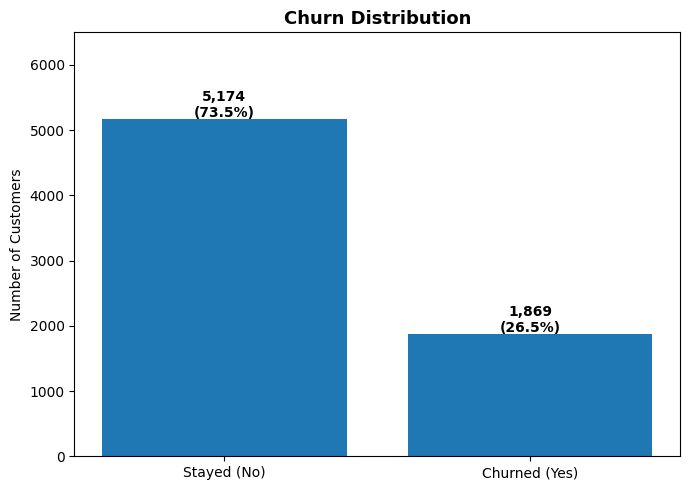

In [95]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()

print('\nChurn Distribution:')
print(f'  Stayed  (No) : {churn_counts["No"]:,}  ({churn_counts["No"]/len(df)*100:.1f}%)')
print(f'  Churned (Yes): {churn_counts["Yes"]:,}  ({churn_counts["Yes"]/len(df)*100:.1f}%)')
print('\n Class Imbalance detected')

plt.figure(figsize=(7, 5))

bars = plt.bar(['Stayed (No)', 'Churned (Yes)'], churn_counts.values)

for bar, val in zip(bars, churn_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.title('Churn Distribution', fontweight='bold', fontsize=13)
plt.ylabel('Number of Customers')
plt.ylim(0, 6500)

plt.tight_layout()
plt.show()

####  2. Exploratory Data Analysis (EDA)


C:\Users\Nandhidha\AppData\Local\Temp\ipykernel_18104\2149154112.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, ax=axes[1,0], palette=['#2ecc71', '#e74c3c'])
C:\Users\Nandhidha\AppData\Local\Temp\ipykernel_18104\2149154112.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Stayed (0)', 'Churned (1)'])
C:\Users\Nandhidha\AppData\Local\Temp\ipykernel_18104\2149154112.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_clean, ax=axes[1,1],palette=['#2ecc71', '#e74c3c'])
C:\Users\Nandhidha\AppData\L

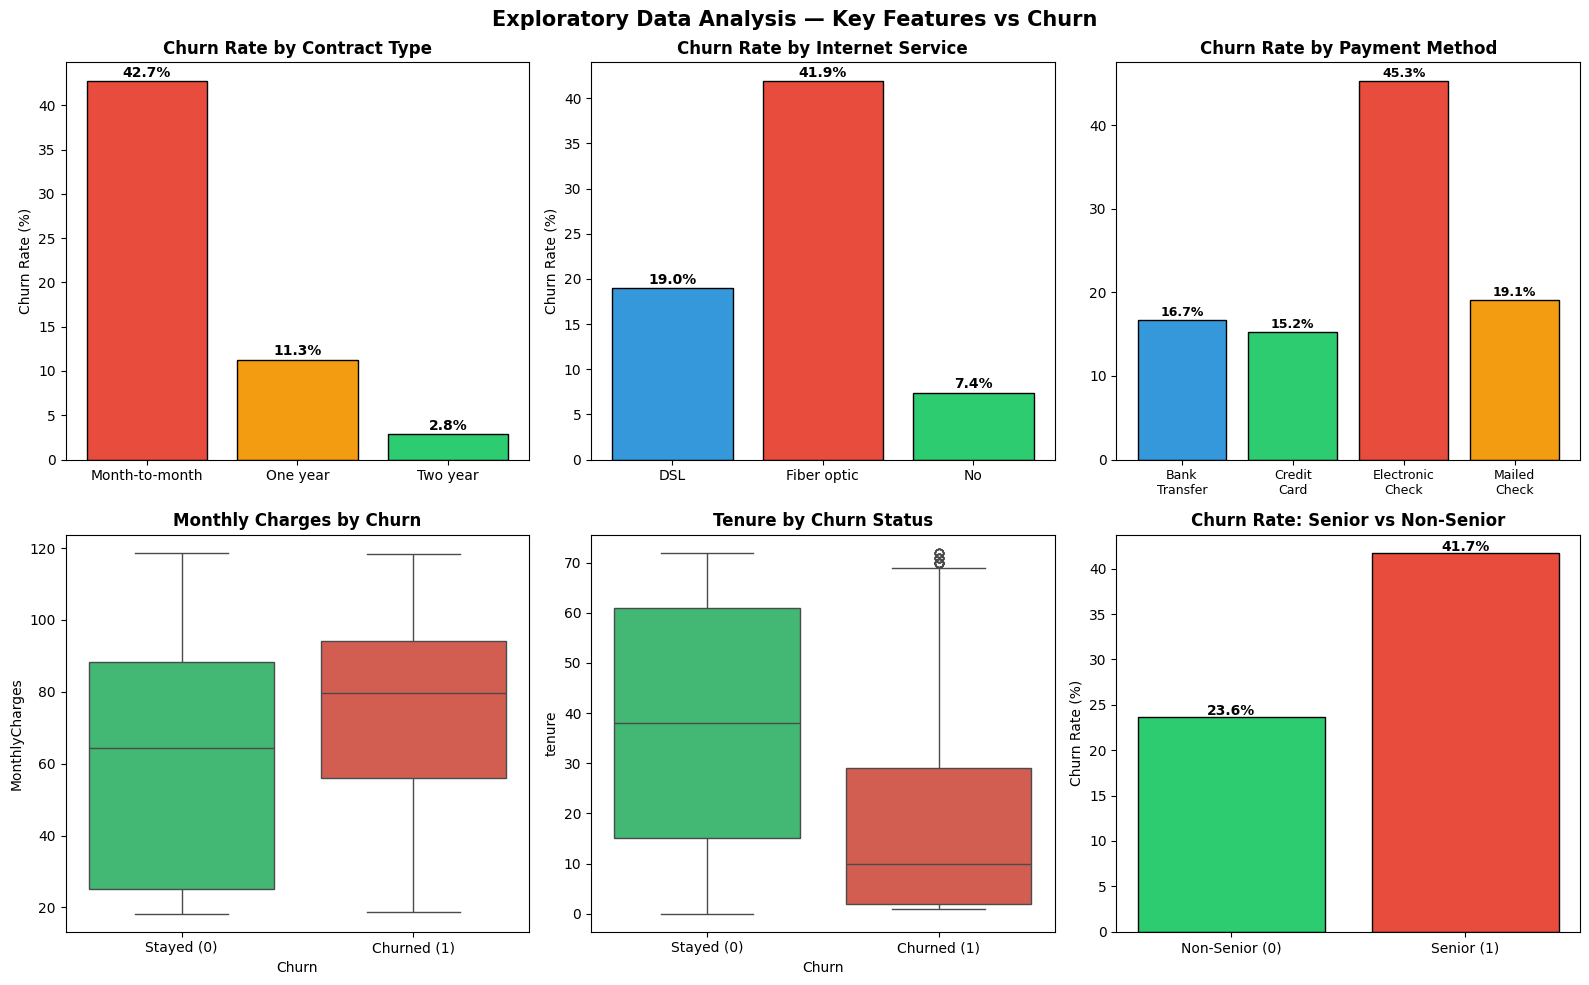


 Key EDA Insights:
  Month-to-month churn rate : 42.7%  ← highest risk contract
  Fiber optic churn rate    : 41.9%  ← highest risk internet
  Electronic check churn    : 45.3%  ← highest risk payment
  Senior citizen churn rate : 41.7%  vs non-senior 23.6%


In [77]:

# EDA — Key Features vs Churn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Contract type
contract_churn = df_clean.groupby('Contract')['Churn'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values,
              color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[0,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
for i, val in enumerate(contract_churn.values):
    axes[0,0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Internet Service
internet_churn = df_clean.groupby('InternetService')['Churn'].mean() * 100
axes[0,1].bar(internet_churn.index, internet_churn.values,
              color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
axes[0,1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
for i, val in enumerate(internet_churn.values):
    axes[0,1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

pay_churn = df_clean.groupby('PaymentMethod')['Churn'].mean() * 100
short_labels = ['Bank\nTransfer', 'Credit\nCard', 'Electronic\nCheck', 'Mailed\nCheck']
axes[0,2].bar(range(len(pay_churn)), pay_churn.values,
              color=['#3498db','#2ecc71','#e74c3c','#f39c12'], edgecolor='black')
axes[0,2].set_xticks(range(len(pay_churn)))
axes[0,2].set_xticklabels(short_labels, fontsize=9)
axes[0,2].set_title('Churn Rate by Payment Method', fontweight='bold')
for i, val in enumerate(pay_churn.values):
    axes[0,2].text(i, val+0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Monthly Charges boxplot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, ax=axes[1,0], palette=['#2ecc71', '#e74c3c'])
axes[1,0].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1,0].set_xticklabels(['Stayed (0)', 'Churned (1)'])


sns.boxplot(x='Churn', y='tenure', data=df_clean, ax=axes[1,1],palette=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Tenure by Churn Status', fontweight='bold')
axes[1,1].set_xticklabels(['Stayed (0)', 'Churned (1)'])

senior_churn = df_clean.groupby('SeniorCitizen')['Churn'].mean() * 100
axes[1,2].bar(['Non-Senior (0)', 'Senior (1)'], senior_churn.values,
              color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1,2].set_title('Churn Rate: Senior vs Non-Senior', fontweight='bold')
axes[1,2].set_ylabel('Churn Rate (%)')
for i, val in enumerate(senior_churn.values):
    axes[1,2].text(i, val+0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Exploratory Data Analysis — Key Features vs Churn',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Key EDA Insights:')
print(f'  Month-to-month churn rate : {contract_churn["Month-to-month"]:.1f}%  ← highest risk contract')
print(f'  Fiber optic churn rate    : {internet_churn["Fiber optic"]:.1f}%  ← highest risk internet')
print(f'  Electronic check churn    : {pay_churn["Electronic check"]:.1f}%  ← highest risk payment')
print(f'  Senior citizen churn rate : {senior_churn[1]:.1f}%  vs non-senior {senior_churn[0]:.1f}%')


#### 2. Clean Dataset


In [76]:
# Check missing values
print('\n Missing Value Check:')
print(df.isnull().sum())
print(f'\n  Total NaN values: {df.isnull().sum().sum()}')
print('\nTotalCharges has HIDDEN missing values — blank spaces stored as text!')
blank_check = (df['TotalCharges'].str.strip() == '').sum()
print(f'   Blank spaces in TotalCharges: {blank_check}')


# Converting TotalCharges
df_clean = df.copy()

df_clean['TotalCharges'] = df_clean['TotalCharges'].str.strip()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

median_tc = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_tc)

print(f'   TotalCharges fixed:')
print(f'   Dtype before: object (string)')
print(f'   Dtype after : {df_clean["TotalCharges"].dtype}')
print(f'   11 blank values filled with median = {median_tc:.2f}')
print(f'   Remaining NaN: {df_clean["TotalCharges"].isnull().sum()}')


# Convert Churn Yes/No → 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print(f' Churn converted: Yes→1, No→0')
print(f' Churn value counts: {df_clean["Churn"].value_counts().to_dict()}')


# Drop customerID
df_clean = df_clean.drop(columns=['customerID'])
print(f' customerID dropped')

# Remove duplicates
dups = df_clean.duplicated().sum()
print(f'\n Duplicate rows found: {dups}')
print('   Retaining duplicates — different customers can have same profile')

print(f'\n Final clean shape: {df_clean.shape}')
print(f'   Features: {df_clean.shape[1]-1} | Target: Churn')



 Missing Value Check:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

  Total NaN values: 0

TotalCharges has HIDDEN missing values — blank spaces stored as text!
   Blank spaces in TotalCharges: 11
   TotalCharges fixed:
   Dtype before: object (string)
   Dtype after : float64
   11 blank values filled with median = 1397.47
   Remaining NaN: 0
 Churn converted: Yes→1, No→0
 Churn value counts: {0: 5174, 1: 1869}
 customerID dropped

 Duplicate rows found: 22
   Retaining duplicates — different customers can have same profile

 Final clean shape: (7043, 20)
   Fea

Implementations done in data cleaning  
1. `TotalCharges` is stored as string now converted into numeric
2. `TotalCharges` has 11 blank spaces that has been treated as missing values now filled with median value
3. `Churn` is Yes/No string — has been converted to 1/0
4. `customerID` has been be dropped (identifier, not a feature)
5.  22 duplicate rows identified and retained

#### 4.Encode Categorical Variables


Strategy:
- Label Encoding → Binary columns (only 2 unique values like Yes/No, Male/Female)
- One-Hot Encoding → Multi-class columns (3+ unique values like Contract type)

In [79]:
# Identify categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)} total):')
for col in cat_cols:
    unique_vals = df_clean[col].unique()
    print(f'  {col:<22}: {len(unique_vals)} unique → {list(unique_vals)[:4]}')
df_encoded = df_clean.copy()

# Label Encoding — binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']
le = LabelEncoder()
le_mappings = {}
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('Label Encoding Applied:')
for col, mapping in le_mappings.items():
    print(f'  {col:<20}: {mapping}')

# One-Hot Encoding — multi-class columns
multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=False)

# Convert bool to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'\n One-Hot Encoding Applied to: {multi_cols}')
print(f'\n Shape after encoding:')
print(f'   Before: (7043, 20)  →  After: {df_encoded.shape}')
print(f'   Features expanded from 19 → {df_encoded.shape[1]-1} (due to one-hot columns)')
    


Categorical columns (15 total):
  gender                : 2 unique → ['Female', 'Male']
  Partner               : 2 unique → ['Yes', 'No']
  Dependents            : 2 unique → ['No', 'Yes']
  PhoneService          : 2 unique → ['No', 'Yes']
  MultipleLines         : 3 unique → ['No phone service', 'No', 'Yes']
  InternetService       : 3 unique → ['DSL', 'Fiber optic', 'No']
  OnlineSecurity        : 3 unique → ['No', 'Yes', 'No internet service']
  OnlineBackup          : 3 unique → ['Yes', 'No', 'No internet service']
  DeviceProtection      : 3 unique → ['No', 'Yes', 'No internet service']
  TechSupport           : 3 unique → ['No', 'Yes', 'No internet service']
  StreamingTV           : 3 unique → ['No', 'Yes', 'No internet service']
  StreamingMovies       : 3 unique → ['No', 'Yes', 'No internet service']
  Contract              : 3 unique → ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling      : 2 unique → ['Yes', 'No']
  PaymentMethod         : 4 unique → ['Electron

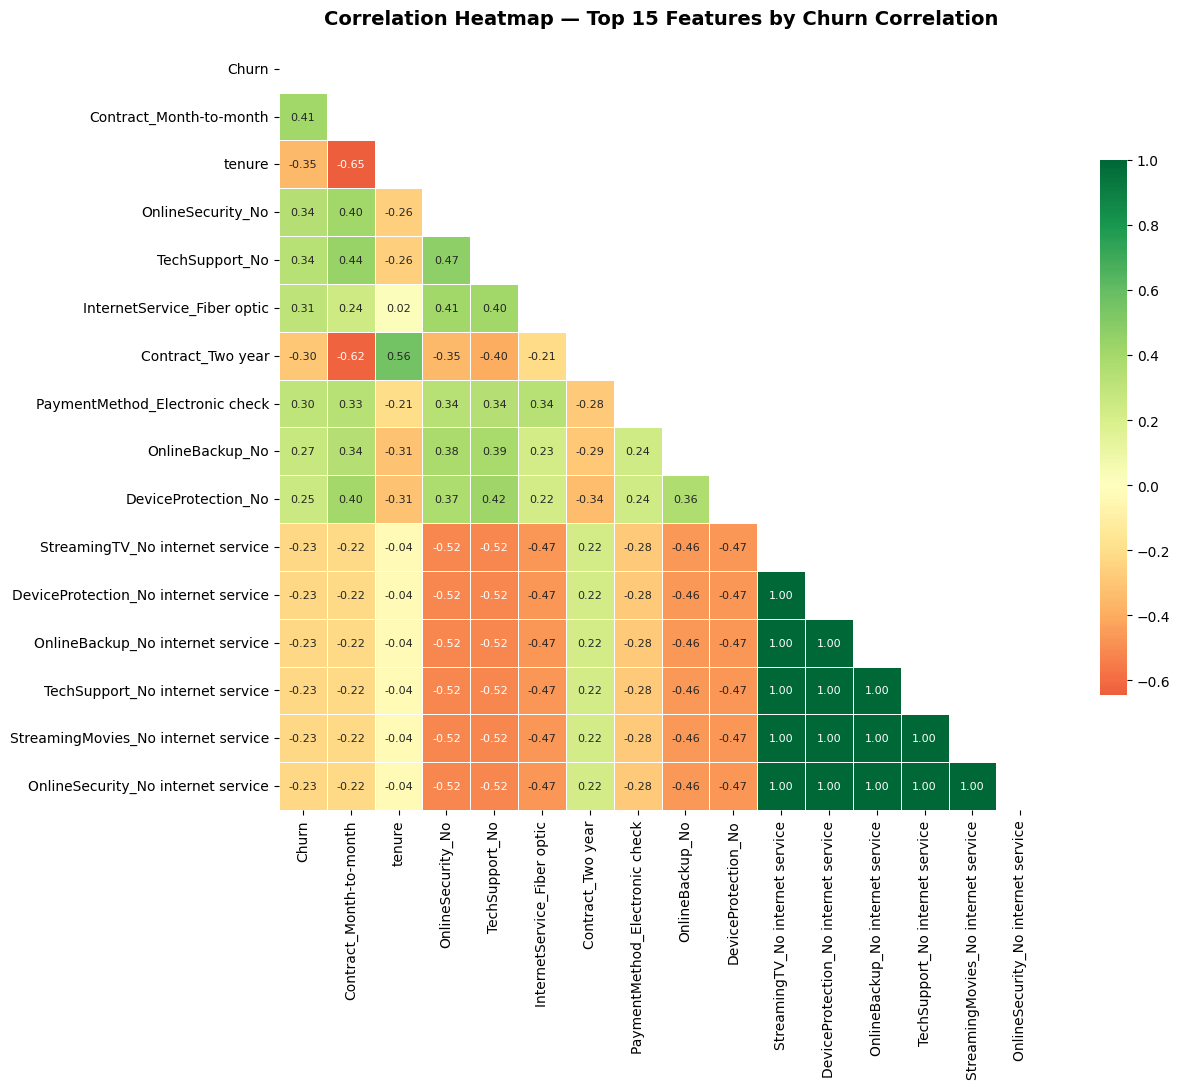


 Top 10 Features Correlated with Churn:
   Increases churn risk → Contract_Month-to-month                 : +0.4051
   Decreases churn risk → tenure                                  : -0.3522
   Increases churn risk → OnlineSecurity_No                       : +0.3426
   Increases churn risk → TechSupport_No                          : +0.3373
   Increases churn risk → InternetService_Fiber optic             : +0.3080
   Decreases churn risk → Contract_Two year                       : -0.3023
   Increases churn risk → PaymentMethod_Electronic check          : +0.3019
   Increases churn risk → OnlineBackup_No                         : +0.2680
   Increases churn risk → DeviceProtection_No                     : +0.2525
   Decreases churn risk → OnlineSecurity_No internet service      : -0.2279


In [80]:
# Correlation Heatmap
top_features = df_encoded.corr()['Churn'].abs().sort_values(ascending=False).head(16).index.tolist()
corr_subset  = df_encoded[top_features].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 15 Features by Churn Correlation',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False).head(10)
print('\n Top 10 Features Correlated with Churn:')
for feat, val in churn_corr.items():
    direction = ' Increases' if val > 0 else ' Decreases'
    print(f'  {direction} churn risk → {feat:<40}: {val:+.4f}')
    


#### 5. Handle Class Imbalance + Train-Test Split



Problem: 73.5% Stayed vs 26.5% Churned — model will be biased toward majority class

Solution: Oversample the minority class (Churned) in the training set only


In [81]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\n Train-Test Split (80/20 Stratified):')
print(f'   Training: {X_train.shape[0]:,} rows | Stayed={( y_train==0).sum():,} | Churned={(y_train==1).sum():,}')
print(f'   Testing : {X_test.shape[0]:,}  rows | Stayed={(y_test==0).sum():,}  | Churned={(y_test==1).sum():,}')

# Oversampling — minority class in training set
X_train_combined = pd.concat([X_train, y_train], axis=1)
stayed  = X_train_combined[X_train_combined['Churn'] == 0]
churned = X_train_combined[X_train_combined['Churn'] == 1]

churned_upsampled = resample(churned, replace=True,
                              n_samples=len(stayed), random_state=42)
train_balanced = pd.concat([stayed, churned_upsampled])
X_train_bal = train_balanced.drop(columns=['Churn'])
y_train_bal  = train_balanced['Churn']

print(f'\n After Oversampling (training set only):')
print(f'   Stayed : {(y_train_bal==0).sum():,} | Churned: {(y_train_bal==1).sum():,}')
print(f'   Balance: 50% / 50%')

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)
print('\n StandardScaler applied (for Logistic Regression)')


Feature matrix X: (7043, 38)
Target vector  y: (7043,)

 Train-Test Split (80/20 Stratified):
   Training: 5,634 rows | Stayed=4,139 | Churned=1,495
   Testing : 1,409  rows | Stayed=1,035  | Churned=374

 After Oversampling (training set only):
   Stayed : 4,139 | Churned: 4,139
   Balance: 50% / 50%

 StandardScaler applied (for Logistic Regression)


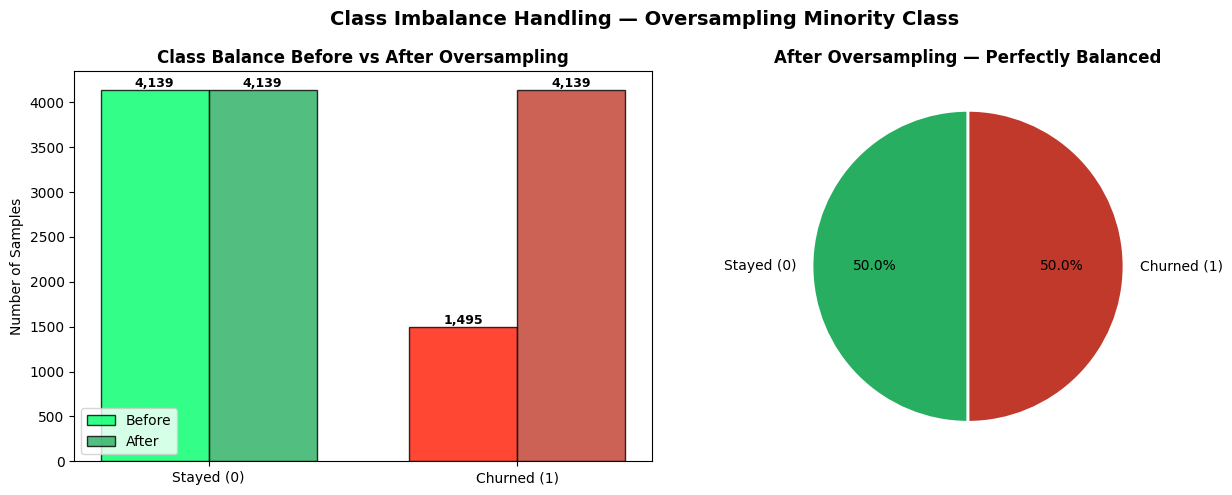

In [82]:
# Visualize class balance before vs after
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

before_vals = [(y_train==0).sum(), (y_train==1).sum()]
after_vals  = [(y_train_bal==0).sum(), (y_train_bal==1).sum()]
labels = ['Stayed (0)', 'Churned (1)']
x = np.arange(len(labels))
width = 0.35

b1 = axes[0].bar(x - width/2, before_vals, width, label='Before', color=["#00ff6a", "#ff1900"], edgecolor='black', alpha=0.8)
b2 = axes[0].bar(x + width/2, after_vals,  width, label='After',  color=['#27ae60','#c0392b'], edgecolor='black', alpha=0.8)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Class Balance Before vs After Oversampling', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].legend()

axes[1].pie(after_vals, labels=labels, colors=['#27ae60','#c0392b'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('After Oversampling — Perfectly Balanced', fontweight='bold')
plt.suptitle('Class Imbalance Handling — Oversampling Minority Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



#### 6. Train 4 Machine Learning Models


The model used here are Logistic Regression, Decision Tree, Random Forest and Gradient Boosting

In [83]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}
trained_models = {}

print(' Training Models...')

for name, model in models.items():
    print(f'\n   {name}...')
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train_bal)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'y_pred': y_pred, 'y_prob': y_prob
    }
    trained_models[name] = model
    r = results[name]
    print(f'      Acc={r["Accuracy"]} | Prec={r["Precision"]} | Rec={r["Recall"]} | F1={r["F1-Score"]} | AUC={r["ROC-AUC"]}')



 Training Models...

   Logistic Regression...
      Acc=0.7317 | Prec=0.4966 | Rec=0.7781 | F1=0.6062 | AUC=0.8412

   Decision Tree...
      Acc=0.7268 | Prec=0.4903 | Rec=0.746 | F1=0.5917 | AUC=0.7917

   Random Forest...
      Acc=0.7722 | Prec=0.5718 | Rec=0.5642 | F1=0.568 | AUC=0.8187

   Gradient Boosting...
      Acc=0.7495 | Prec=0.5186 | Rec=0.7834 | F1=0.6241 | AUC=0.8466


#### 7. Model Comparison & Evaluation


In [ ]:
# Model Comparison Table
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['y_pred','y_prob']}
    for name, vals in results.items()
}).T.astype(float)

print('\n MODEL COMPARISON TABLE')
print('-' * 65)
print(metrics_df.sort_values('ROC-AUC', ascending=False).to_string())
best_auc = metrics_df['ROC-AUC'].idxmax()
best_f1  = metrics_df['F1-Score'].idxmax()

print(f'\n   Best by ROC-AUC : {best_auc}  ({metrics_df.loc[best_auc,"ROC-AUC"]:.4f})')
print(f'   Best by F1-Score: {best_f1}  ({metrics_df.loc[best_f1,"F1-Score"]:.4f})')



 MODEL COMPARISON TABLE
-----------------------------------------------------------------
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gradient Boosting      0.7495     0.5186  0.7834    0.6241   0.8466
Logistic Regression    0.7317     0.4966  0.7781    0.6062   0.8412
Random Forest          0.7722     0.5718  0.5642    0.5680   0.8187
Decision Tree          0.7268     0.4903  0.7460    0.5917   0.7917

   Best by ROC-AUC : Gradient Boosting  (0.8466)
   Best by F1-Score: Gradient Boosting  (0.6241)


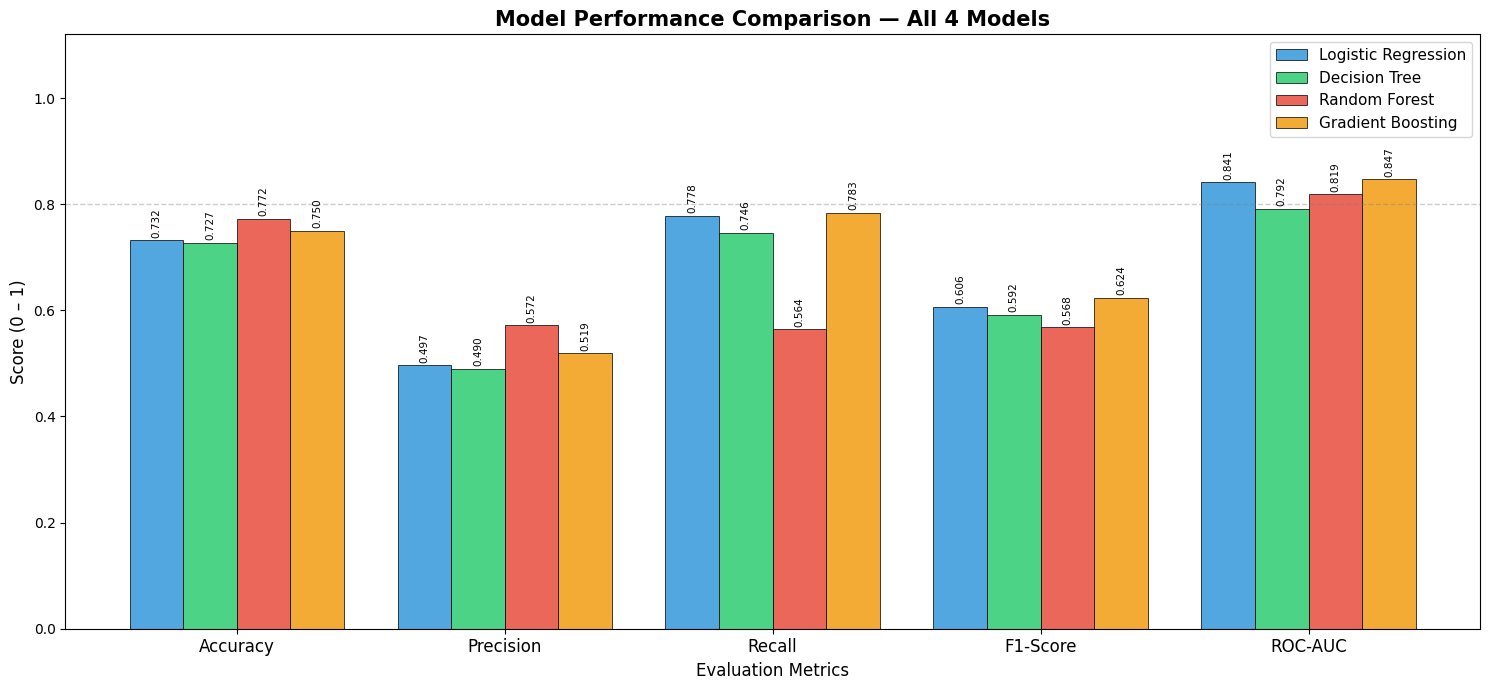

In [86]:
# Bar Chart Comparison
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_plot))
width = 0.2
COLORS = ['#3498db','#2ecc71','#e74c3c','#f39c12']


fig, ax = plt.subplots(figsize=(15, 7))
for i, (name, color) in enumerate(zip(results.keys(), COLORS)):
    vals = [results[name][m] for m in metrics_plot]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=color, alpha=0.85, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)
ax.set_xlabel('Evaluation Metrics', fontsize=12)
ax.set_ylabel('Score (0 – 1)', fontsize=12)
ax.set_title('Model Performance Comparison — All 4 Models', fontsize=15, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_plot, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1, label='0.8 reference')
plt.tight_layout()
plt.show()


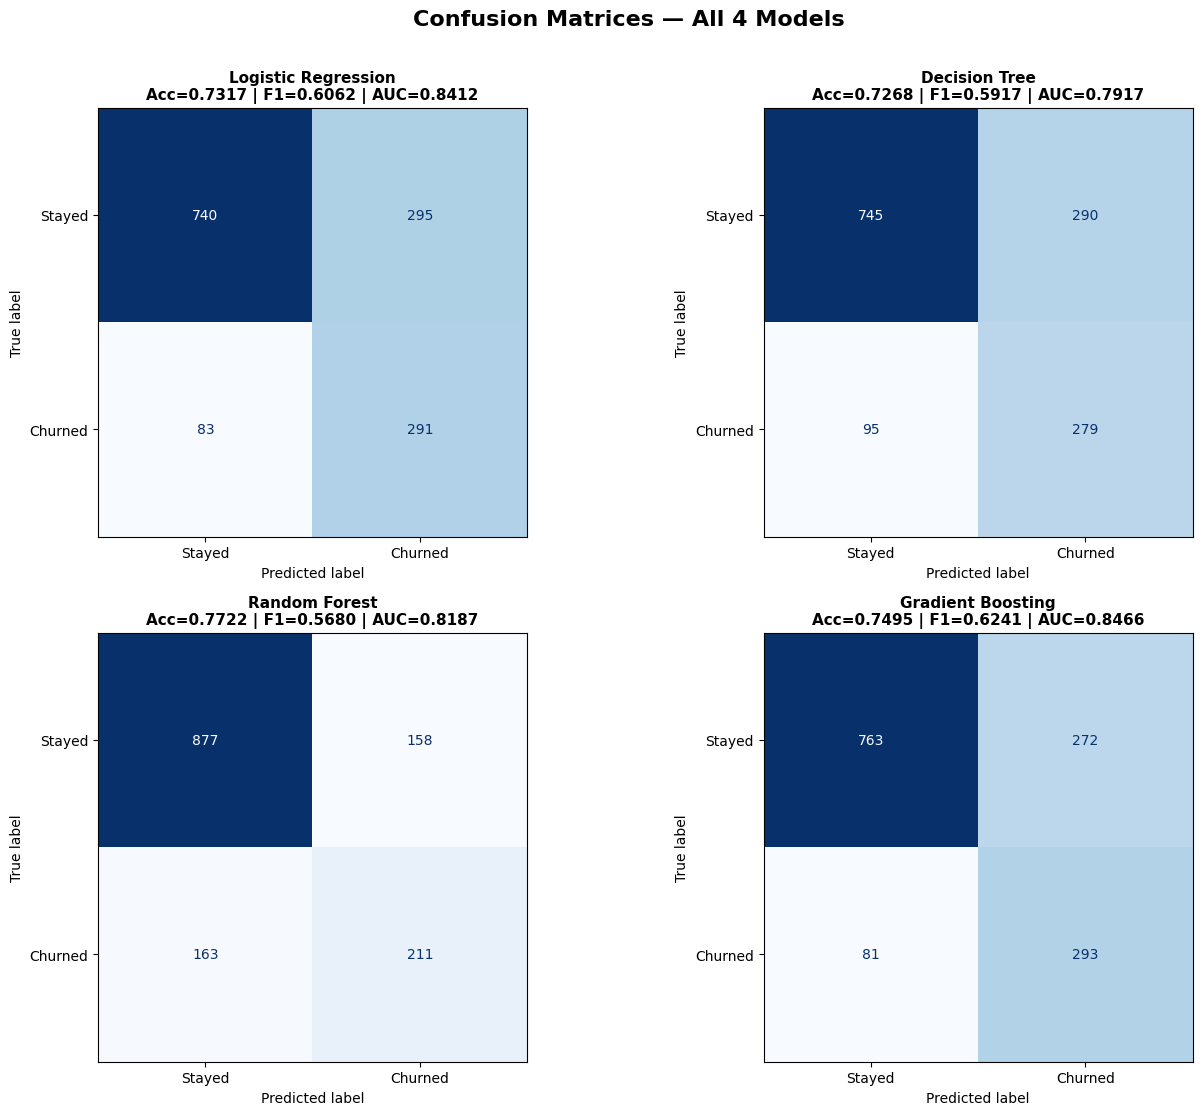

In [87]:
# Confusion Matrices — All 4 Models
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
for i, (name, vals) in enumerate(results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(
        f'{name}\nAcc={vals["Accuracy"]:.4f} | F1={vals["F1-Score"]:.4f} | AUC={vals["ROC-AUC"]:.4f}',
        fontweight='bold', fontsize=11)
plt.suptitle('Confusion Matrices — All 4 Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


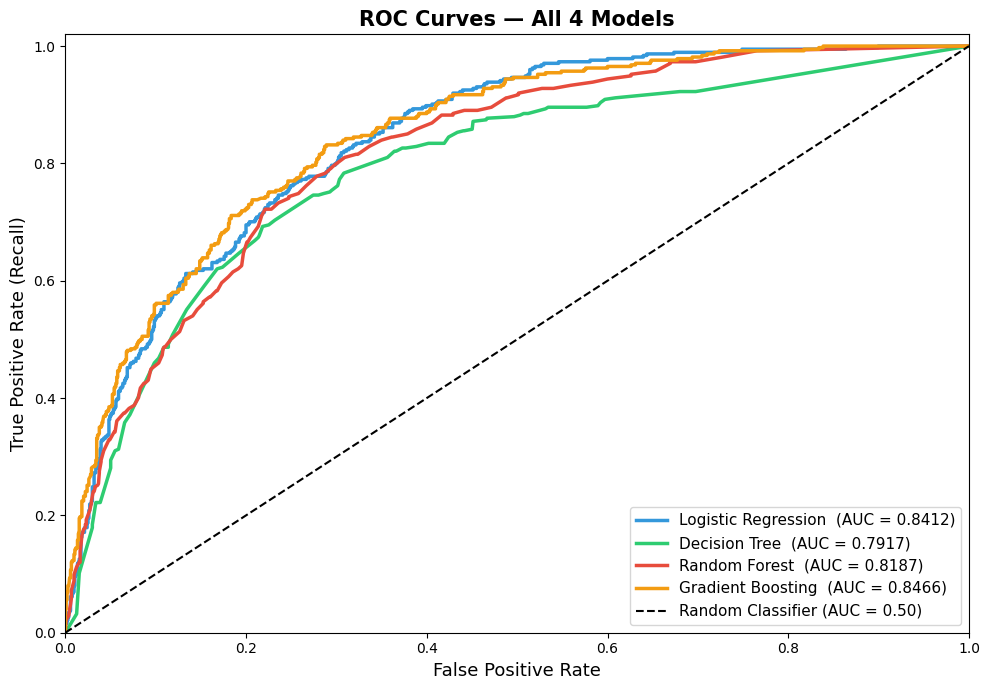

In [88]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))
for (name, vals), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    ax.plot(fpr, tpr, lw=2.5, label=f'{name}  (AUC = {vals["ROC-AUC"]:.4f})', color=color)
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curves — All 4 Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()


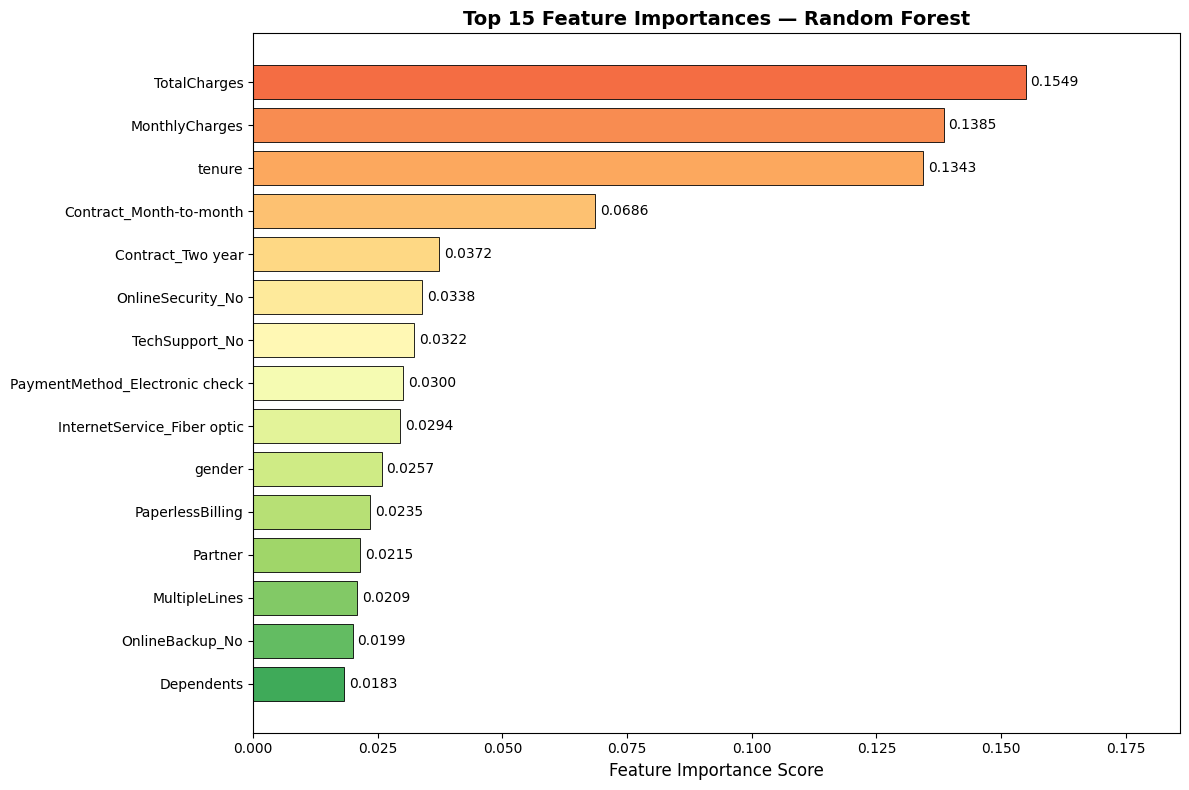


Top 5 Churn Predictors:
   → TotalCharges: 0.1549
   → MonthlyCharges: 0.1385
   → tenure: 0.1343
   → Contract_Month-to-month: 0.0686
   → Contract_Two year: 0.0372


In [89]:
# Feature Importance — Random Forest
rf_model = trained_models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train_bal.columns)
feat_imp_top = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(feat_imp_top)))[::-1]
bars = ax.barh(feat_imp_top.index[::-1], feat_imp_top.values[::-1],
               color=colors_fi, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, feat_imp_top.values[::-1]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlim(0, feat_imp_top.max()*1.2)
plt.tight_layout()
plt.show()

print('\nTop 5 Churn Predictors:')
for feat, imp in feat_imp_top.head(5).items():
    print(f'   → {feat}: {imp:.4f}')
    


In [90]:
# Classification Reports — Separate cells to avoid truncation
print('\nCLASSIFICATION REPORTS — ALL 4 MODELS')
for name, vals in results.items():
    print(f'\n{"═"*58}')
    print(f'  {name}')
    print(f'{"═"*58}')
    print(classification_report(y_test, vals['y_pred'],
                                target_names=['Stayed', 'Churned']))
    



CLASSIFICATION REPORTS — ALL 4 MODELS

══════════════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.90      0.71      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409


══════════════════════════════════════════════════════════
  Decision Tree
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.89      0.72      0.79      1035
     Churned       0.49      0.75      0.59       374

    accuracy                           0.73      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.73      0.74      1409


══════════════════════════════

#### 8. Rule-Based Churn Logic


A simple interpretable system using **6 domain-driven rules** specific to telecom churn.

| Rule | Signal | Why |
|------|--------|-----|
| Contract = Month-to-month | +1 | No long-term commitment → easiest to leave |
| Tenure < 12 months | +1 | New customer → no loyalty built yet |
| MonthlyCharges > $70 | +1 | High bill → more likely to comparison shop |
| InternetService = Fiber optic | +1 | Fiber customers churn at 41.9% |
| PaymentMethod = Electronic check | +1 | Highest churn payment method |
| No TechSupport (with internet) | +1 | Unresolved issues → frustration |

**Score ≥ 3 → HIGH RISK → Predict Churn = 1**  
**Score = 2 → MEDIUM RISK → Predict Churn = 0 (monitor)**  
**Score ≤ 1 → LOW RISK → Predict Churn = 0**

In [91]:
df_rules = df_clean.copy()

def rule_based_churn(row):
    score = 0; flags = []
    if row['Contract'] == 'Month-to-month':                           score+=1; flags.append('MonthToMonth')
    if row['tenure'] < 12:                                            score+=1; flags.append('LowTenure')
    if row['MonthlyCharges'] > 70:                                    score+=1; flags.append('HighMonthlyCharges')
    if row['InternetService'] == 'Fiber optic':                       score+=1; flags.append('FiberOptic')
    if row['PaymentMethod'] == 'Electronic check':                    score+=1; flags.append('ElectronicCheck')
    if row['TechSupport'] == 'No' and row['InternetService'] != 'No': score+=1; flags.append('NoTechSupport')

    if score >= 3:   return 1, 'HIGH',   score, '|'.join(flags) if flags else 'None'
    elif score == 2: return 0, 'MEDIUM', score, '|'.join(flags) if flags else 'None'
    else:            return 0, 'LOW',    score, '|'.join(flags) if flags else 'None'

rule_results = df_rules.apply(rule_based_churn, axis=1)
df_rules['Rule_Pred']  = [r[0] for r in rule_results]
df_rules['Risk_Level'] = [r[1] for r in rule_results]
df_rules['Risk_Score'] = [r[2] for r in rule_results]
df_rules['Risk_Flags'] = [r[3] for r in rule_results]

rule_y_true = df_clean['Churn'].values
rule_y_pred = df_rules['Rule_Pred'].values

rule_acc  = accuracy_score(rule_y_true, rule_y_pred)
rule_prec = precision_score(rule_y_true, rule_y_pred)
rule_rec  = recall_score(rule_y_true, rule_y_pred)
rule_f1   = f1_score(rule_y_true, rule_y_pred)

print('\n Rule-Based System Performance:')
print(f'  Accuracy : {rule_acc:.4f}')
print(f'  Precision: {rule_prec:.4f}')
print(f'  Recall   : {rule_rec:.4f}  ← catches {rule_rec*100:.1f}% of all actual churners')
print(f'  F1-Score : {rule_f1:.4f}')

risk_counts = df_rules['Risk_Level'].value_counts()
print(f'\n  Risk Distribution:')
for level in ['HIGH','MEDIUM','LOW']:
    val = risk_counts.get(level, 0)
    print(f'    {level:8}: {val:,}  ({val/len(df_rules)*100:.1f}%)')

print('\n Classification Report:')
print(classification_report(rule_y_true, rule_y_pred, target_names=['Stayed','Churned']))



 Rule-Based System Performance:
  Accuracy : 0.6842
  Precision: 0.4493
  Recall   : 0.8411  ← catches 84.1% of all actual churners
  F1-Score : 0.5857

  Risk Distribution:
    HIGH    : 3,499  (49.7%)
    MEDIUM  : 1,340  (19.0%)
    LOW     : 2,204  (31.3%)

 Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.63      0.74      5174
     Churned       0.45      0.84      0.59      1869

    accuracy                           0.68      7043
   macro avg       0.68      0.73      0.67      7043
weighted avg       0.79      0.68      0.70      7043



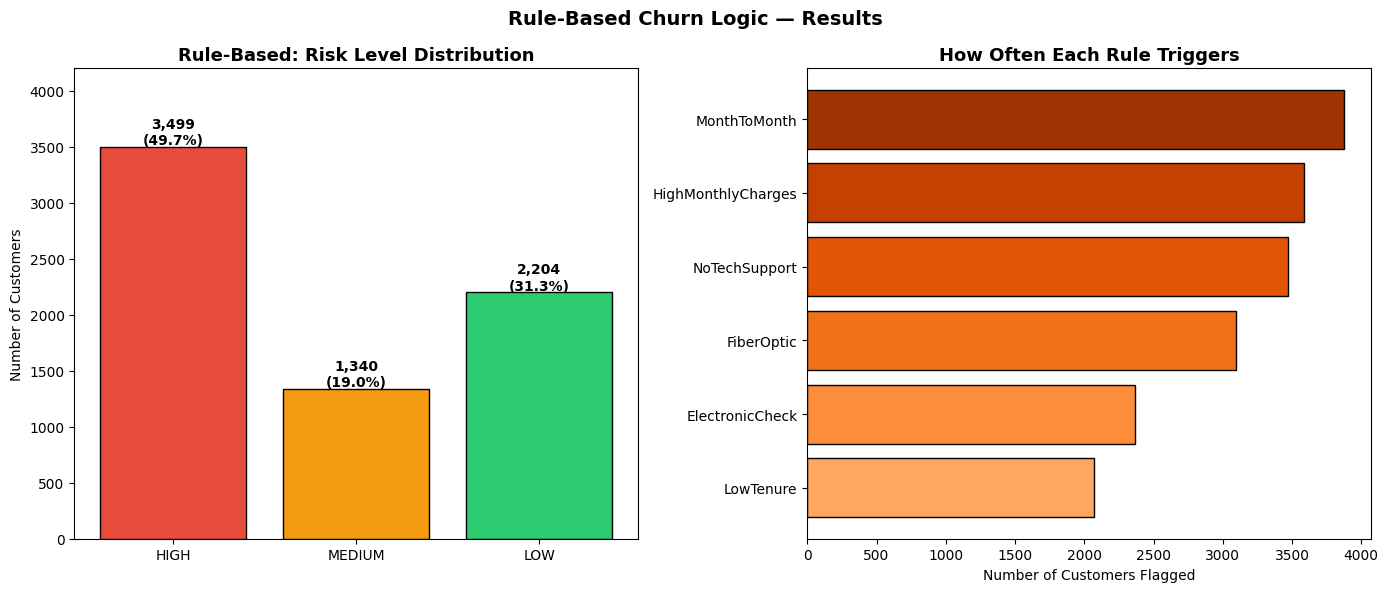


Sample HIGH RISK Customers:
 tenure       Contract  MonthlyCharges InternetService           PaymentMethod TechSupport  Risk_Score                                                                         Risk_Flags  Churn
      1 Month-to-month           29.85             DSL        Electronic check          No           4                               MonthToMonth|LowTenure|ElectronicCheck|NoTechSupport      0
      2 Month-to-month           53.85             DSL            Mailed check          No           3                                               MonthToMonth|LowTenure|NoTechSupport      1
      2 Month-to-month           70.70     Fiber optic        Electronic check          No           6 MonthToMonth|LowTenure|HighMonthlyCharges|FiberOptic|ElectronicCheck|NoTechSupport      1
      8 Month-to-month           99.65     Fiber optic        Electronic check          No           6 MonthToMonth|LowTenure|HighMonthlyCharges|FiberOptic|ElectronicCheck|NoTechSupport      1
     2

In [92]:
# Rule-Based Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

risk_order  = ['HIGH', 'MEDIUM', 'LOW']
risk_vals   = [risk_counts.get(r,0) for r in risk_order]
risk_colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(risk_order, risk_vals, color=risk_colors, edgecolor='black')
for bar, val in zip(bars, risk_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{val:,}\n({val/len(df_rules)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Rule-Based: Risk Level Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(risk_vals)*1.2)

all_flags = '|'.join(df_rules['Risk_Flags']).split('|')
flag_freq  = pd.Series(all_flags).value_counts().drop('None', errors='ignore').head(8)
f_colors   = plt.cm.Oranges(np.linspace(0.4, 0.9, len(flag_freq)))
axes[1].barh(flag_freq.index[::-1], flag_freq.values[::-1], color=f_colors, edgecolor='black')
axes[1].set_title('How Often Each Rule Triggers', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Customers Flagged')
plt.suptitle('Rule-Based Churn Logic — Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSample HIGH RISK Customers:')
print(df_rules[df_rules['Risk_Level']=='HIGH'][[
    'tenure','Contract','MonthlyCharges','InternetService',
    'PaymentMethod','TechSupport','Risk_Score','Risk_Flags','Churn'
]].head(6).to_string(index=False))



#### 9. Which Model is Best? — Final Verdict


In [93]:
# Final Summary
print('       TELCO CUSTOMER CHURN PREDICTION — SUMMARY')
print(f'  Dataset : IBM Telco | {df.shape[0]:,} customers | 20 features')
print(f'  Churn Rate: {df_clean["Churn"].mean()*100:.1f}%  (realistic imbalanced data)')
print(f'  Preprocessing: Missing values fixed, Encoded, Oversampled')
print()
print('  ML Models Trained & Compared:')
for i,(name,vals) in enumerate(sorted(results.items(), key=lambda x:-x[1]['ROC-AUC']),1):
    print(f'  {i}. {name:<25} F1={vals["F1-Score"]:.4f} | AUC={vals["ROC-AUC"]:.4f}')
print()
print(f'  Rule-Based System:           F1={rule_f1:.4f} | Recall={rule_rec:.4f} (interpretable)')
print()
best = max(results, key=lambda n: results[n]['ROC-AUC'])
print(f'   BEST MODEL: {best}')
print(f'     Reason: Highest ROC-AUC ({results[best]["ROC-AUC"]}) + F1 ({results[best]["F1-Score"]})')
print(f'     Best balance of Precision & Recall for real-world churn detection')

metrics_df_export = metrics_df.copy()
metrics_df_export.loc['Rule-Based Logic'] = [rule_acc, rule_prec, rule_rec, rule_f1, None]
metrics_df_export.round(4).to_csv('model_comparison_results.csv')
df_rules[df_rules['Risk_Level']=='HIGH'].to_csv('high_risk_customers.csv', index=False)
print('\n Results saved: model_comparison_results.csv')
print(' High-risk list saved: high_risk_customers.csv')

       TELCO CUSTOMER CHURN PREDICTION — SUMMARY
  Dataset : IBM Telco | 7,043 customers | 20 features
  Churn Rate: 26.5%  (realistic imbalanced data)
  Preprocessing: Missing values fixed, Encoded, Oversampled

  ML Models Trained & Compared:
  1. Gradient Boosting         F1=0.6241 | AUC=0.8466
  2. Logistic Regression       F1=0.6062 | AUC=0.8412
  3. Random Forest             F1=0.5680 | AUC=0.8187
  4. Decision Tree             F1=0.5917 | AUC=0.7917

  Rule-Based System:           F1=0.5857 | Recall=0.8411 (interpretable)

   BEST MODEL: Gradient Boosting
     Reason: Highest ROC-AUC (0.8466) + F1 (0.6241)
     Best balance of Precision & Recall for real-world churn detection

 Results saved: model_comparison_results.csv
 High-risk list saved: high_risk_customers.csv



#### Final Results Table

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------|-----------|--------|----------|----------|
| Logistic Regression | 0.7317 | 0.4966 | 0.7781 | 0.6062 | 0.8412 |
| Decision Tree | 0.7268 | 0.4903 | 0.7460 | 0.5917 | 0.7917 |
| Random Forest | 0.7722 | 0.5718 | 0.5642 | 0.5680 | 0.8187 |
| **Gradient Boosting** | 0.7495 | 0.5186 | **0.7834** | **0.6241** | **0.8466** |
| Rule-Based Logic | 0.6842 | 0.4493 | 0.8411 | 0.5857 | N/A |
